In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


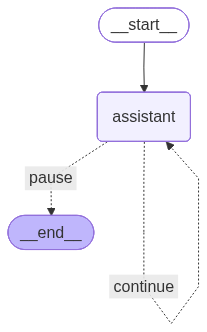

In [3]:
from typing_extensions import TypedDict
from typing import List, Literal

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

class State(MessagesState):
    step: int

llm = ChatPerplexity(model="sonar-pro")

def assistant(state: State) -> State:
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": messages + [response], "step": state["step"] + 1}

def should_pause(state: State) -> Literal["pause", "continue"]:
    return "pause" if state["step"] == 1 else "continue"

workflow = StateGraph(State)
workflow.add_node("assistant", assistant)
workflow.set_entry_point("assistant")
workflow.add_conditional_edges("assistant", should_pause, 
                               {"pause": END, "continue": "assistant"})

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "breakpoint-demo-1"}}

initial = {"messages": [HumanMessage(content="Explain what cloud computing is.")], "step": 0}

print("Running until first breakpoint...\n")
for event in graph.stream(initial, config=thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

Running until first breakpoint...

================================ Human Message =================================

Explain what cloud computing is.
----------------------------------------
================================== Ai Message ==================================

Cloud computing is a technology model that allows individuals and organizations to access computing resources—such as servers, storage, databases, networking, software, and analytics—over the internet, rather than owning and managing physical hardware and infrastructure themselves. These resources are hosted in remote data centers by cloud service providers and can be used on-demand, typically with a pay-as-you-go pricing structure.

Key characteristics of cloud computing include:

- **On-demand self-service:** Users can provision computing resources as needed, automatically, without requiring direct interaction with the service provider.
- **Broad network access:** Services are accessible over the internet from a var

In [5]:
print("Resuming from checkpoint after first breakpoint...\n")
for event in graph.stream(None, config=thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

Resuming from checkpoint after first breakpoint...

================================== Ai Message ==================================

Cloud computing is a technology model that allows individuals and organizations to access computing resources—such as servers, storage, databases, networking, software, and analytics—over the internet, rather than owning and managing physical hardware and infrastructure themselves. These resources are hosted in remote data centers by cloud service providers and can be used on-demand, typically with a pay-as-you-go pricing structure.

Key characteristics of cloud computing include:

- **On-demand self-service:** Users can provision computing resources as needed, automatically, without requiring direct interaction with the service provider.
- **Broad network access:** Services are accessible over the internet from a variety of devices.
- **Rapid elasticity:** Resources can be scaled up or down quickly to meet changing needs.
- **Measured service:** Usage i

In [6]:
thread2 = {"configurable": {"thread_id": "breakpoint-demo-2"}}

initial2 = {"messages": [HumanMessage(content="Give a one-line definition of machine learning.")], "step": 0}

print("Running second breakpoint example...\n")
for event in graph.stream(initial2, config=thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Resuming second example...\n")
for event in graph.stream(None, config=thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

Running second breakpoint example...

================================ Human Message =================================

Give a one-line definition of machine learning.
----------------------------------------
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence that enables computers to learn from data and make predictions or decisions without being explicitly programmed.[1][2]
----------------------------------------
Resuming second example...

================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence that enables computers to learn from data and make predictions or decisions without being explicitly programmed.[1][2]
----------------------------------------
